In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/qingyi/wm811k-wafer-map/LSWMD.pkl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
df = pd.read_pickle(
    "/kaggle/input/datasets/qingyi/wm811k-wafer-map/LSWMD.pkl"
)

print(df.head())
print(f"總筆數: {len(df):,}")               
print(f"欄位: {list(df.columns)}")                                                                                                                                                        
print(f"\n記憶體佔用: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
                                                                                                                                                                                            
print("\n第 1 筆:")                     
row = df.iloc[0]                                                                                                                                                                          
print(f"  waferMap 型態: {type(row['waferMap'])}, shape={row['waferMap'].shape}")                                                                                                         
print(f"  waferMap 值範圍: {row['waferMap'].min()} ~ {row['waferMap'].max()}")
print(f"  dieSize: {row['dieSize']}")                                                                                                                                                     
print(f"  lotName: {row['lotName']}")                     
print(f"  waferIndex: {row['waferIndex']}")                                                                                                                                               
print(f"  trianTestLabel: {row['trianTestLabel']}  (type={type(row['trianTestLabel']).__name__})")
print(f"  failureType: {row['failureType']}  (type={type(row['failureType']).__name__})")                                                                                                 
                                                            


                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLabel failureType  
0         1.0   [[Training]]    [[none]]  
1         2.0   [[Training]]    [[none]]  
2         3.0   [[Training]]    [[none]]  
3         4.0   [[Training]]    [[none]]  
4         5.0   [[Training]]    [[none]]  
總筆數: 811,457
欄位: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

記憶體佔用: 629 MB

第 1 筆:
  waferMap 型態: <class 'numpy.ndarray'>, shape=(45, 48)
  waferMap 值範圍: 0 ~ 2
  dieSize: 1683.0
  lotName: lot1
  waferIndex: 1.0
  trianTestLabel: [['Training']]  (type=ndarray)
  f

In [3]:
# ═══════════════════════════════════════                                                                                                                                                 
# 抽取標籤（從巢狀 array 拿字串）
# ═══════════════════════════════════════ 
def extract_str(x):
    """處理 [[' none ']] 這種巢狀結構，拿內層字串並去空白"""  
    if isinstance(x, np.ndarray) and x.size > 0:
        v = x[0][0] if x.ndim == 2 else x[0]
        return v.strip() if isinstance(v, str) else "" 
    return ""
df['label'] = df['failureType'].apply(extract_str)
df['split'] = df['trianTestLabel'].apply(extract_str)

print("failureType 抽完後的所有值：")
print(df['label'].value_counts(dropna=False))
print(f"\ntrianTestLabel 抽完後：")
print(df['split'].value_counts(dropna=False))

# ═══════════════════════════════════════                 
# 過濾到有效標籤                                                                                                                                                                          
# ═══════════════════════════════════════ 
CLASSES = ['Center','Donut','Edge-Loc','Edge-Ring','Loc',
           'Random','Scratch','Near-full','none']
labeled = df[df['label'].isin(CLASSES)].reset_index(drop=True).copy()
print(f"\n[Labeled] 有效標籤筆數: {len(labeled):,}")
print(f"[Unlabeled] 無標籤筆數: {len(df) - len(labeled):,}")

# ═══════════════════════════════════════
# 類別分布 + 不平衡診斷                                                                                                                                                                   
# ═══════════════════════════════════════
print("\n" + "="*50)
print("類別分佈")
print("="*50)
cls_count = labeled['label'].value_counts()
cls_pct = labeled['label'].value_counts(normalize=True) * 100

for cls in cls_count.index:
    bar = "█" * int(cls_pct[cls] / 2) #每 2% 一格
    print(f" {cls:12s} {cls_count[cls]:>7,} ({cls_pct[cls]:5.2f}%) {bar}")

print(f"\n最多 vs 最少 = {cls_count.max():,} : {cls_count.min():,}")
print(f"不平衡比例 = {cls_count.max() / cls_count.min():.0f} : 1")

failureType 抽完後的所有值：
label
             638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

trianTestLabel 抽完後：
split
            638507
Test        118595
Training     54355
Name: count, dtype: int64

[Labeled] 有效標籤筆數: 172,950
[Unlabeled] 無標籤筆數: 638,507

類別分佈
 none         147,431 (85.24%) ██████████████████████████████████████████
 Edge-Ring      9,680 ( 5.60%) ██
 Edge-Loc       5,189 ( 3.00%) █
 Center         4,294 ( 2.48%) █
 Loc            3,593 ( 2.08%) █
 Scratch        1,193 ( 0.69%) 
 Random           866 ( 0.50%) 
 Donut            555 ( 0.32%) 
 Near-full        149 ( 0.09%) 

最多 vs 最少 = 147,431 : 149
不平衡比例 = 989 : 1


In [ ]:
import matplotlib.pyplot as plt
# ═══════════════════════════════════════
# 尺寸分布（決定 resize）
# ═══════════════════════════════════════
labeled['h'] = labeled['waferMap'].apply(lambda x: x.shape[0])
labeled['w'] = labeled['waferMap'].apply(lambda x: x.shape[1])
print("整體尺寸統計")
print(labeled[['h','w']].describe().round(1))

print("\n各類別的中位數尺寸")
print(labeled.groupby('label')[['h','w']].median().astype(int).sort_values('h'))

#分布圖
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(labeled['h'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(64, color='red', linestyle='--', label='64px')
axes[0].axvline(96, color='green', linestyle="--", label='96px')
axes[0].set_title(f'Height (median={labeled["h"].median():.0f})')
axes[0].legend()

axes[1].hist(labeled['w'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(64, color='red', linestyle="--", label='64px')
axes[1].axvline(96, color='green', linestyle="--", label='96px')
axes[1].set_title(f'Width (median={labeled["w"].median():.0f})')
axes[1].legend()

axes[2].scatter(labeled['w'], labeled['h'], alpha=0.1, s=5)
axes[2].set_title('H vs W')
axes[2].set_xlabel('Width'); axes[2].set_ylabel('Height')
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════
# 每類抽 5 張視覺化
# ═══════════════════════════════════════
CLASSES_ORDER = ['none', 'Edge-Ring', 'Edge-Loc', 'Center', 'Loc',
                 'Scratch', 'Random', 'Donut', 'Near-full']
n_samples = 5
fig, axes = plt.subplots(9, n_samples, figsize=(n_samples*2.2, 9*2.2))
for i, cls in enumerate(CLASSES_ORDER):
    cls_df = labeled[labeled['label']==cls]
    samples = cls_df.sample(min(n_samples, len(cls_df)), random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        axes[i, j].imshow(row['waferMap'], cmap='viridis', aspect='equal')
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        if j == 0:
            axes[i, j].set_ylabel(f"{cls}\n(n={len(cls_df)})",
                                   fontsize=9, rotation=0, ha='right', va='center',
                                    labelpad=30)
plt.suptitle('Sample wafer maps (5 per class)', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
#過濾異常尺寸（h/w >= 20）
labeled = labeled[(labeled['h'] >= 20) & (labeled['w'] >= 20)].reset_index(drop=True)
print(f"過濾後: {len(labeled):,}") 

過濾後: 172,941


In [7]:
# Downsample "none" 到 5000 筆
NONE_SIZE = 5000

none_sample = labeled[labeled['label']=='none'].sample(n=NONE_SIZE, random_state=42)
others = labeled[labeled['label']!='none'] # 除了 none 以外全部留

train_pool = pd.concat([none_sample, others]).reset_index(drop=True)
print(f"訓練池：{len(train_pool):,}")
print(train_pool['label'].value_counts())

訓練池：30,516
label
Edge-Ring    9680
Edge-Loc     5189
none         5000
Center       4294
Loc          3591
Scratch      1193
Random        865
Donut         555
Near-full     149
Name: count, dtype: int64


In [8]:
# 建立 label → int 映射
CLASSES = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 
           'Loc', 'Random', 'Scratch', 'Near-full']
label_to_idx = {cls_name: idx for idx, cls_name in enumerate(CLASSES)}
idx_to_label = {idx: cls_name for cls_name, idx in label_to_idx.items()}
print(label_to_idx)
print(idx_to_label)

{'none': 0, 'Center': 1, 'Donut': 2, 'Edge-Loc': 3, 'Edge-Ring': 4, 'Loc': 5, 'Random': 6, 'Scratch': 7, 'Near-full': 8}
{0: 'none', 1: 'Center', 2: 'Donut', 3: 'Edge-Loc', 4: 'Edge-Ring', 5: 'Loc', 6: 'Random', 7: 'Scratch', 8: 'Near-full'}


In [9]:
#Resize + Normalize
IMG_SIZE = 64

def preprocess_wafer(wm):
    """
    input : numpy array, 值 {0,1,2}, shape 不定
    output: numpy array float32, shape (64,64), 值 [0,1]
    """ 
    resized = cv2.resize(
        wm.astype(np.uint8),
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    normalized = resized.astype(np.float32) / 2.0
    return normalized

In [10]:
#套用到全部資料
X = np.stack([preprocess_wafer(wm) for wm in train_pool['waferMap']])
y = np.array([label_to_idx[lbl] for lbl in train_pool['label']])
# ═══════════════════════════════════════                 
# 驗證（不用改）                                                                                                                                                                 
# ═══════════════════════════════════════                                                                                                                                                 
print(f"\n=== 驗證 ===")                    
print(f"X.shape:  {X.shape}   （期望 (~30000, 64, 64)）")                                                                                                                                 
print(f"X.dtype:  {X.dtype}   （期望 float32）")          
print(f"X[0] 值域: [{X[0].min()}, {X[0].max()}]  （期望 [0.0, 1.0]）")                                                                                                                    
print(f"y.shape:  {y.shape}, dtype: {y.dtype}")
print(f"y 前 20:  {y[:20]}")                                                                                                                                                              
print(f"y 分布:   {dict(zip(CLASSES, np.bincount(y)))}") 


=== 驗證 ===
X.shape:  (30516, 64, 64)   （期望 (~30000, 64, 64)）
X.dtype:  float32   （期望 float32）
X[0] 值域: [0.0, 1.0]  （期望 [0.0, 1.0]）
y.shape:  (30516,), dtype: int64
y 前 20:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
y 分布:   {'none': np.int64(5000), 'Center': np.int64(4294), 'Donut': np.int64(555), 'Edge-Loc': np.int64(5189), 'Edge-Ring': np.int64(9680), 'Loc': np.int64(3591), 'Random': np.int64(865), 'Scratch': np.int64(1193), 'Near-full': np.int64(149)}


In [11]:
# 第一刀：train (70%) vs temp (30%)
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# 第二刀：temp 再切成 val 和 test 各 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# 驗證
print(f"Train: {X_train.shape}, y 分布: {np.bincount(y_train)}")
print(f"Val:   {X_val.shape}, y 分布: {np.bincount(y_val)}")
print(f"Test:  {X_test.shape}, y 分布: {np.bincount(y_test)}")                                                                                                                            
                                              
# 驗證每個 split 都有 9 類                                                                                                                                                                
assert len(np.unique(y_train)) == 9, "Train 少了某個類別！"
assert len(np.unique(y_val)) == 9,   "Val 少了某個類別！"                                                                                                                                 
assert len(np.unique(y_test)) == 9,  "Test 少了某個類別！"
print("\n✅ 每個 split 都有 9 類")                                                                                                                                                        
                                                                                                                                                                                            
# 驗證比例一致                          
for i, cls in enumerate(CLASSES):                                                                                                                                                         
    total = (y_train==i).sum() + (y_val==i).sum() + (y_test==i).sum()                                                                                                                     
    train_pct = (y_train==i).sum() / total * 100                                                                                                                                          
    val_pct   = (y_val==i).sum()   / total * 100                                                                                                                                          
    test_pct  = (y_test==i).sum()  / total * 100          
    print(f"  {cls:12s}  train {train_pct:.1f}% | val {val_pct:.1f}% | test {test_pct:.1f}%")

Train: (21361, 64, 64), y 分布: [3500 3006  389 3632 6776 2514  605  835  104]
Val:   (4577, 64, 64), y 分布: [ 750  644   83  778 1452  538  130  179   23]
Test:  (4578, 64, 64), y 分布: [ 750  644   83  779 1452  539  130  179   22]

✅ 每個 split 都有 9 類
  none          train 70.0% | val 15.0% | test 15.0%
  Center        train 70.0% | val 15.0% | test 15.0%
  Donut         train 70.1% | val 15.0% | test 15.0%
  Edge-Loc      train 70.0% | val 15.0% | test 15.0%
  Edge-Ring     train 70.0% | val 15.0% | test 15.0%
  Loc           train 70.0% | val 15.0% | test 15.0%
  Random        train 69.9% | val 15.0% | test 15.0%
  Scratch       train 70.0% | val 15.0% | test 15.0%
  Near-full     train 69.8% | val 15.4% | test 14.8%


In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

#自訂 Dataset 類別
class WaferMapDataset(Dataset):
    def __init__(self, X, y):
        """
        X: numpy array, shape (N, 64, 64), float32
        y: numpy array, shape (N,), int64
        """
        self.X = torch.from_numpy(X).unsqueeze(1)
        self.y = torch.from_numpy(y).long()
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

#建三個 dataset
train_ds = WaferMapDataset(X_train, y_train)
val_ds = WaferMapDataset(X_val, y_val)
test_ds = WaferMapDataset(X_test, y_test)

#驗證 Dataset                                                                                                                                                                            
print(f"Train dataset size: {len(train_ds)}")                                                                                                                                             
sample_x, sample_y = train_ds[0]            
print(f"Sample X shape: {sample_x.shape}  （期望 [1, 64, 64]）")                                                                                                                          
print(f"Sample X dtype: {sample_x.dtype}   （期望 torch.float32）")
print(f"Sample y: {sample_y}, dtype: {sample_y.dtype}  （期望 torch.int64）")  

#建 DataLoader
BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

#驗證 batch
for x_batch, y_batch in train_loader:
    print(f"\n=== Batch 檢查 ===")                        
    print(f"X batch shape: {x_batch.shape}")
    print(f"X batch dtype: {x_batch.dtype}")                                                                                                                                              
    print(f"y batch shape: {y_batch.shape}")
    print(f"y batch 前 20: {y_batch[:20]}")                                                                                                                   
    break

Train dataset size: 21361
Sample X shape: torch.Size([1, 64, 64])  （期望 [1, 64, 64]）
Sample X dtype: torch.float32   （期望 torch.float32）
Sample y: 3, dtype: torch.int64  （期望 torch.int64）

=== Batch 檢查 ===
X batch shape: torch.Size([128, 1, 64, 64])
X batch dtype: torch.float32
y batch shape: torch.Size([128])
y batch 前 20: tensor([3, 1, 3, 3, 4, 1, 5, 4, 4, 1, 4, 4, 1, 1, 0, 5, 5, 1, 5, 7])


In [13]:
import torch.nn as nn                                                                                                                                                                     
import torch.nn.functional as F                           

                                          
class BaselineCNN(nn.Module):           
  def __init__(self, num_classes=9):
      super().__init__()                                                                                                                                                                

      # ─── Block 1 ─────────────────                                                                                                                                                   
      # Input:  [B, 1, 64, 64]                          
      # Output: [B, 32, 32, 32] (after pool)
      self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1)
      self.bn1   = nn.BatchNorm2d(32)    
                                                                                                                                                                                        
      # ─── Block 2 ─────────────────
      # Input:  [B, 32, 32, 32]                                                                                                                                                         
      # Output: [B, 64, 16, 16]                         
      self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)                                                                                               
      self.bn2   = nn.BatchNorm2d(64)                  
                                                                                                                                                                                        
      # ─── Block 3 ─────────────────
      # Input:  [B, 64, 16, 16]                                                                                                                                                         
      # Output: [B, 128, 8, 8]                          
      self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)                                                                                               
      self.bn3   = nn.BatchNorm2d(128)                  
                                                                                                                                                                                        
      # ─── Head ────────────────────
      self.pool = nn.MaxPool2d(2)              # 空間減半                                                                                                                               
      self.gap  = nn.AdaptiveAvgPool2d(1)      # 全域平均池化 → [B, C, 1, 1]
      self.fc   = nn.Linear(in_features=128, out_features=num_classes)                                                                                                                          
                                                        
  def forward(self, x):                                                                                                                                                                 
      # x: [B, 1, 64, 64]                                                                                                                                                               
      x = self.pool(F.relu(self.bn1(self.conv1(x))))   # → [B, 32, 32, 32]                                                                                                              
      x = self.pool(F.relu(self.bn2(self.conv2(x))))   # → [B, 64, 16, 16]                                                                                                              
      x = self.pool(F.relu(self.bn3(self.conv3(x))))   # → [B, 128, 8, 8]                                                                                                               
                                                        
      x = self.gap(x)              # → [B, 128, 1, 1]                                                                                                                                   
      x = x.flatten(1)             # → [B, 128]
      x = self.fc(x)               # → [B, 9]                                                                                                                                           
      return x                                                                                                                                                                          
                                                                                                                                                                                        
                                                                                                                                                                                        
# ═══════════════════════════════════════                 
# 驗證
# ═══════════════════════════════════════                                                                                                                                                 
model = BaselineCNN(num_classes=9)
print(model)                                                                                                                                                                              
                                                        
# Forward pass 測試
with torch.no_grad():                                                                                                                                                                     
  dummy_input = torch.randn(2, 1, 64, 64)
  dummy_output = model(dummy_input)                                                                                                                                                     
  print(f"\nInput  shape: {dummy_input.shape}")         
  print(f"Output shape: {dummy_output.shape}")
                                                                                                                                                                                        
# 參數量                                
total_params = sum(p.numel() for p in model.parameters())                                                                                                                                 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)                                                                                                                 
print(f"\nTotal params: {total_params:,}")  
print(f"Trainable:    {trainable:,}")

BaselineCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=128, out_features=9, bias=True)
)

Input  shape: torch.Size([2, 1, 64, 64])
Output shape: torch.Size([2, 9])

Total params: 94,281
Trainable:    94,281


In [14]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = BaselineCNN(num_classes=9).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

N_EPOCHS = 10

# ═══════════════════════════════════════                 
# Training Loop
# ═══════════════════════════════════════ 
best_val_acc = 0.0
history = {'train_loss':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_batches = 0

    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [train]"):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_batches += 1
    train_loss = train_loss_sum / train_batches

    # ─── VAL 階段 ─────────────────
    model.eval() #關閉 train mode
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            val_loss_sum += loss.item() * y_batch.size(0) #這裡乘 batch size 為了算 mean

            preds = logits.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")
   
    # ─── 存最佳 model ───────────── 
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/kaggle/working/best_model.pt')
        print(f"Saved best model (val_acc={val_acc:.4f})")

print(f"\n=== 訓練完成 ===")                                                                                                                                                              
print(f"Best val accuracy: {best_val_acc:.4f}")


Using device: cuda


Epoch 1/10 [train]: 100%|██████████| 167/167 [00:05<00:00, 31.82it/s]


Epoch 1: train_loss=1.0697 | val_loss=1.0784 | val_acc=0.5676
Saved best model (val_acc=0.5676)


Epoch 2/10 [train]: 100%|██████████| 167/167 [00:03<00:00, 42.33it/s]


Epoch 2: train_loss=0.7879 | val_loss=0.7935 | val_acc=0.7337
Saved best model (val_acc=0.7337)


...

Epoch 8: train_loss=0.4865 | val_loss=0.5539 | val_acc=0.8018
Saved best model (val_acc=0.8018)


Epoch 9/10 [train]: 100%|██████████| 167/167 [00:03<00:00, 42.10it/s]


Epoch 9: train_loss=0.4662 | val_loss=0.5503 | val_acc=0.7955


Epoch 10/10 [train]: 100%|██████████| 167/167 [00:04<00:00, 41.62it/s]


Epoch 10: train_loss=0.4499 | val_loss=0.5866 | val_acc=0.7737

=== 訓練完成 ===
Best val accuracy: 0.8018


Test set 總筆數: 4578

Macro F1: 0.7121

Weighted F1: 0.7829

===Per-class Report 
              precision    recall  f1-score   support

        none      0.724     0.940     0.818       750
      Center      0.944     0.727     0.821       644
       Donut      0.586     0.614     0.600        83
    Edge-Loc      0.957     0.462     0.623       779
   Edge-Ring      0.927     0.996     0.960      1452
         Loc      0.497     0.807     0.615       539
      Random      0.865     0.885     0.875       130
     Scratch      0.646     0.173     0.273       179
   Near-full      0.724     0.955     0.824        22

    accuracy                          0.793      4578
   macro avg      0.763     0.729     0.712      4578
weighted avg      0.831     0.793     0.783      4578



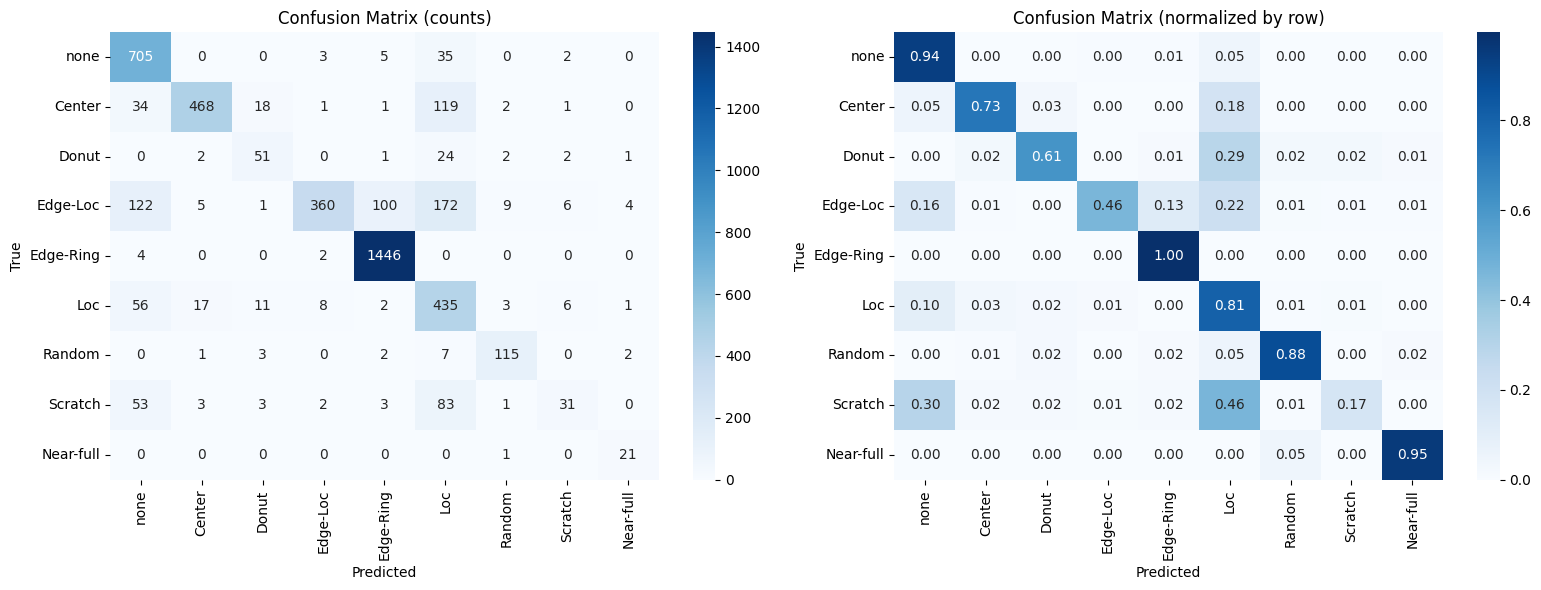

In [15]:
# 目標： 產出 per-class F1 + confusion matrix，看清模型真實實力。 
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# ═══════════════════════════════════════                                                                                                                                                 
# 載入最佳 model                                 
# ═══════════════════════════════════════
model.load_state_dict(torch.load('/kaggle/working/best_model.pt'))
model.eval()

# ═══════════════════════════════════════                                                                                                                                                 
# 在 test set 跑 inference，收集所有預測                                
# ═══════════════════════════════════════
all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)

        logits = model(x_batch)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
print(f"Test set 總筆數: {len(all_preds)}")

# ═══════════════════════════════════════                                                                                                                                                 
# 三種 F1 分數
# ═══════════════════════════════════════
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"\nMacro F1: {macro_f1:.4f}")
print(f"\nWeighted F1: {weighted_f1:.4f}")

# ═══════════════════════════════════════                                                                                                                                                 
# Per-class Classification Report                
# ═══════════════════════════════════════
print("\n===Per-class Report ")
print(classification_report(
    all_labels, all_preds,
    target_names=CLASSES,
    digits=3
))

# ═══════════════════════════════════════                                                                                                                                                 
# Confusion Matrix
# ═══════════════════════════════════════
cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左：原始數字
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',                                                                                                                                        
          xticklabels=CLASSES, yticklabels=CLASSES,     
          ax=axes[0])                                                                                                                                                                   
axes[0].set_title('Confusion Matrix (counts)')            
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')                                                                                                                                                           
                                      
# 右：按 row 標準化（每一類的預測分布）                                                                                                                                                   
cm_norm = cm / cm.sum(axis=1, keepdims=True)                                                                                                                                              
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
          xticklabels=CLASSES, yticklabels=CLASSES,                                                                                                                                     
          ax=axes[1])                                   
axes[1].set_title('Confusion Matrix (normalized by row)')                                                                                                                                 
axes[1].set_ylabel('True')                                
axes[1].set_xlabel('Predicted')                                                                                                                                                           
                                                        
plt.tight_layout()                                                                                                                                                                        
plt.show()

我第一版 baseline CNN 打到 macro F1 0.717，主要弱點在 Scratch（recall 只有 1.7%）和 Donut（recall 42%），這兩類都是樣本少 + 特徵細，被 resize 到 64 抹掉。

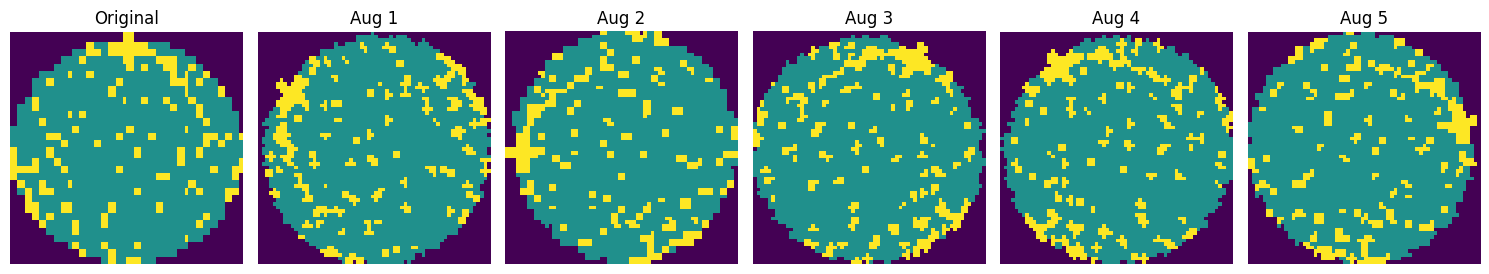

In [16]:
from torchvision.transforms import v2

train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(
        degrees=180,
        interpolation=v2.InterpolationMode.NEAREST,
    )
])

#val / test 不做 augmentation
val_transform = None

# ═══════════════════════════════════════                 
# 改寫 Dataset 支援 transform  
# ═══════════════════════════════════════
class WaferMapDataset(Dataset):

    def __init__(self, X, y, transform=None):
        self.X = torch.from_numpy(X).unsqueeze(1)
        self.y = torch.from_numpy(y).long()
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, self.y[idx]

# ═══════════════════════════════════════                                                                                                                                                 
# 重建 dataset 和 loader                         
# ═══════════════════════════════════════
train_ds = WaferMapDataset(X_train, y_train, transform=train_transform)

val_ds = WaferMapDataset(X_val, y_val, transform=val_transform)
test_ds = WaferMapDataset(X_test, y_test, transform=val_transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ═══════════════════════════════════════
# 視覺化驗證 augmentation 有效                                                                                                                                                   
# ═══════════════════════════════════════                 
# 抽同一張 wafer 展示 6 種不同的 augmentation
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
sample_x = train_ds.X[0] #transform的原圖

for i, ax in enumerate(axes):
    if i == 0:
        img = sample_x
        title = "Original"
    else:
        img = train_transform(sample_x)
        title = f"Aug {i}"
    ax.imshow(img.squeeze(), cmap='viridis')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
# ═══════════════════════════════════════
# 計算 class weights（balanced：少數類權重放大）
# ═══════════════════════════════════════
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASSES)),
    y=y_train
)

print("Class weights (balanced):")
for cls, w in zip(CLASSES, class_weights):
    print(f"  {cls:12s} {w:.4f}")

# 給 CrossEntropyLoss 用的 tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [ ]:
# ═══════════════════════════════════════
# v2 訓練：augmentation + weighted CE
# （train_loader 已在上面用 train_transform 重建、shuffle=True）
# ═══════════════════════════════════════
model_v2 = BaselineCNN(num_classes=9).to(device)
criterion_v2 = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-3)

N_EPOCHS = 10
best_val_acc_v2 = 0.0
history_v2 = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    model_v2.train()
    train_loss_sum = 0.0
    train_batches = 0

    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [train v2]"):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model_v2(x_batch)
        loss = criterion_v2(logits, y_batch)
        optimizer_v2.zero_grad()
        loss.backward()
        optimizer_v2.step()

        train_loss_sum += loss.item()
        train_batches += 1
    train_loss = train_loss_sum / train_batches

    # ─── VAL ─────────────────
    model_v2.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model_v2(x_batch)
            loss = criterion_v2(logits, y_batch)
            val_loss_sum += loss.item() * y_batch.size(0)

            preds = logits.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history_v2['train_loss'].append(train_loss)
    history_v2['val_loss'].append(val_loss)
    history_v2['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc_v2:
        best_val_acc_v2 = val_acc
        torch.save(model_v2.state_dict(), '/kaggle/working/best_model_v2.pt')
        print(f"Saved best v2 model (val_acc={val_acc:.4f})")

print(f"\n=== v2 訓練完成 ===")
print(f"Best val accuracy: {best_val_acc_v2:.4f}")

In [ ]:
# ═══════════════════════════════════════
# v2 評估：test set → macro F1 + per-class + confusion matrix
# ═══════════════════════════════════════
model_v2.load_state_dict(torch.load('/kaggle/working/best_model_v2.pt'))
model_v2.eval()

all_preds_v2 = []
all_labels_v2 = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model_v2(x_batch)
        preds = logits.argmax(dim=1)
        all_preds_v2.append(preds.cpu())
        all_labels_v2.append(y_batch.numpy())

all_preds_v2 = np.concatenate(all_preds_v2)
all_labels_v2 = np.concatenate(all_labels_v2)

macro_f1_v2 = f1_score(all_labels_v2, all_preds_v2, average='macro')
weighted_f1_v2 = f1_score(all_labels_v2, all_preds_v2, average='weighted')

print(f"[v2] Macro F1:    {macro_f1_v2:.4f}   (v1 baseline: 0.717)")
print(f"[v2] Weighted F1: {weighted_f1_v2:.4f}")

print("\n=== v2 Per-class Report ===")
print(classification_report(
    all_labels_v2, all_preds_v2,
    target_names=CLASSES,
    digits=3
))

# ─── v1 vs v2 per-class F1 對照表 ─────────────────
from sklearn.metrics import f1_score as _f1
f1_v1 = _f1(all_labels, all_preds, average=None)
f1_v2 = _f1(all_labels_v2, all_preds_v2, average=None)

print("=== v1 vs v2 Per-class F1 ===")
print(f"{'Class':12s} {'v1':>7s} {'v2':>7s} {'Δ':>7s}")
for i, cls in enumerate(CLASSES):
    delta = f1_v2[i] - f1_v1[i]
    marker = ' ↑' if delta > 0.02 else (' ↓' if delta < -0.02 else '')
    print(f"{cls:12s} {f1_v1[i]:>7.3f} {f1_v2[i]:>7.3f} {delta:>+7.3f}{marker}")

# ─── Confusion matrix ─────────────────
cm_v2 = confusion_matrix(all_labels_v2, all_preds_v2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('v2 Confusion Matrix (counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

cm_v2_norm = cm_v2 / cm_v2.sum(axis=1, keepdims=True)
sns.heatmap(cm_v2_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('v2 Confusion Matrix (normalized by row)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()